
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the review of your code. **Congratulations! Your project has been accepted.** 🎉

I didn't find any critical issues, and your solution looks solid. Below, you may still find some positive feedback or optional suggestions for future improvements.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



# Instacart Market Basket Analysis

## Importing the required libraries

In [1]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Analyze your data

In [3]:
print(orders.columns)
    

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order'],
      dtype='object')


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In the initial data review, it would be helpful to display a quick preview and structure summary for *each* dataset (e.g., `.head()` and `.info()` for `orders`, `products`, `departments`, `aisles`, and `order_products`). Right now only parts of that overview are shown, which makes it harder to confirm column meanings, dtypes, and missing values across all tables.

</div>


In [4]:
# In this cell, type "products" below this line and execute the cell
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for your analysis.

In [5]:
# In this cell, type "orders.info() below this line and execute the cell
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

In [6]:
# In this cell, run orders_products.info() below, but include the argument show_counts=True since this is a large file.
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

## Find and Remove Missing Values

We noticed that some columns contain missing values.

Here are some useful code snippets:

```python
# Identify missing values in each column
print(dataset.isnull().sum())

# Display rows where a specific column has missing values
print(dataset[dataset['column_name'].isna()])

# Confirm no missing values remain
print(dataset.isnull().sum())
```

### `products` Data Frame

We will begin by addressing the missing values in the `products` data frame.

In [7]:
# Display rows where the product_name column has missing values
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [8]:

# Combine conditions to check for missing product names in aisles other than 100
products[(products['product_name'].isna()) & (products['aisle_id'] != 100)]


,product_id,product_name,aisle_id,department_id


In [9]:
# Combine conditions to check for missing product names in aisles other than 21
products[(products['product_name'].isna()) & (products['department_id'] != 21)]

,product_id,product_name,aisle_id,department_id


To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [10]:
departments[departments['department_id'] == 21]
aisles[aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

When investigating what `department_id == 21` and `aisle_id == 100` represent, only the aisle lookup is visible in the output. Consider printing/displaying the department lookup as well so the conclusion about where missing `product_name` values come from is fully supported.

</div>


In [11]:
# Fill missing product names with 'Unknown'
products['product_name'] = products['product_name'].fillna('unknown')

### `orders` data frame

Now let's fill in missing values from the `orders` table.

In [12]:
# Display rows where the days_since_prior_order column has missing values
orders[(orders['days_since_prior_order'].isna())]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [13]:
# Are there any missing values where it's not a customer's first order?
orders[(orders['order_number'] > 1 ) & (orders['days_since_prior_order'].isna())]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame

Now let's fill in missing values from the order_products table.

In [14]:
# Display rows where the add_to_cart_order column has missing values
order_products[(order_products['add_to_cart_order'].isna())]


,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [15]:
# Use .min() and .max() to find the minimum and maximum values for this column.

print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())


1.0
64.0


In [16]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_orders = order_products[
    order_products['add_to_cart_order'].isna()
]['order_id'].unique()

In [17]:
# Do all orders with missing values have more than 64 products?
order_products[order_products['order_id'].isin(missing_orders)] \
    .groupby('order_id').size() \
    .min() > 64

True

In [18]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)


For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All the Datasets

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our analysis. To handle this:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.
3. Optionally, you can set the `keep` parameter in `.drop_duplicates()` to specify which duplicate to retain (`'first'` or `'last'`).

Here is some example code for reference:
```python
# Check for duplicates
print(dataset.duplicated().sum())  # Number of duplicate rows

# View duplicate rows
print(dataset[dataset.duplicated()]

# Remove duplicates
dataset = dataset.drop_duplicates().reset_index(drop=True)

# Confirm removal
print(dataset.duplicated().sum())  # Should return 0
```

Repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [19]:
# Find the number of duplicate rows in the orders dataframe
orders.duplicated().sum()

15

In [20]:
orders[orders.duplicated()]


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


In [21]:
# Remove duplicate orders
orders = orders.drop_duplicates().reset_index(drop=True)

In [22]:
# Double check for duplicate rows
orders.duplicated().sum()

0

### `products` data frame

In [23]:
# Check for fully duplicate rows
products.duplicated().sum()

0

In [24]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
products.duplicated(subset='product_id').sum()

0

Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [25]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name'].str.lower().duplicated().sum()

1361

Let's see what that looks like in our dataset :

In [26]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,High Performance Energy Drink,64,7
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7


In [27]:
# Drop duplicate product names (case insensitive)
# 1. Create lowercase version of product names
products['product_name_lower'] = products['product_name'].str.lower()

# 2. Drop duplicates using the lowercase column
products = products.drop_duplicates(subset='product_name_lower')

# 3. Remove helper column
products = products.drop(columns='product_name_lower')

# 4. Reset index
products = products.reset_index(drop=True)

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Be cautious about dropping duplicates based on `product_name` (even case-insensitively). Different products can legitimately share the same name while having different `product_id`/metadata, so this step can delete valid products and distort downstream analysis. Consider limiting deduplication to fully duplicated rows (or verifying that these are true duplicates beyond casing) and treating duplicate names as a data-quality signal rather than removing them.

</div>


### `departments` data frame

In [28]:
# Check for duplicate entries in the departments dataframe
departments[departments.duplicated()]

,department_id,department


### `aisles` data frame

In [29]:
# Check for aisles entries in the departments dataframe
aisles[aisles.duplicated()]

,aisle_id,aisle


### `order_products` data frame

In [30]:
# Check for duplicate entries in the order_products dataframe
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


We have now successfully cleaned our data. Let's begin our exploratory data analysis.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

To verify that the values in the `order_hour_of_day` and `order_dow` columns are sensible:

1. **Check unique values**: Use `.unique()` on each column to extract all distinct values present.
2. **Sort the results**: Use `sorted()` to arrange the unique values in ascending order for easier verification.
3. **Validate ranges**:
   - Ensure `order_hour_of_day` values range from 0 to 23 (representing hours of the day).
   - Ensure `order_dow` values range from 0 to 6 (representing days of the week).

This process confirms that the data aligns with expected ranges and there are no out-of-bound or invalid entries.

In [31]:
print(sorted(orders['order_hour_of_day'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work verifying the full expected range (0–23) for `order_hour_of_day` using sorted unique values—this is a clear and effective sanity check.

</div>


In [32]:
print(sorted(orders['order_dow'].unique()))

[0, 1, 2, 3, 4, 5, 6]


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good validation for `order_dow` as well—confirming the values span 0–6 completes the required plausibility check.

</div>


### [A2] What time of day do people shop for groceries?

To determine the time of day people shop for groceries, analyze the order_hour_of_day column in the orders dataset. Use .value_counts() to count the number of orders placed at each hour, and then sort the results by the hour for a clear chronological order.

Finally, visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


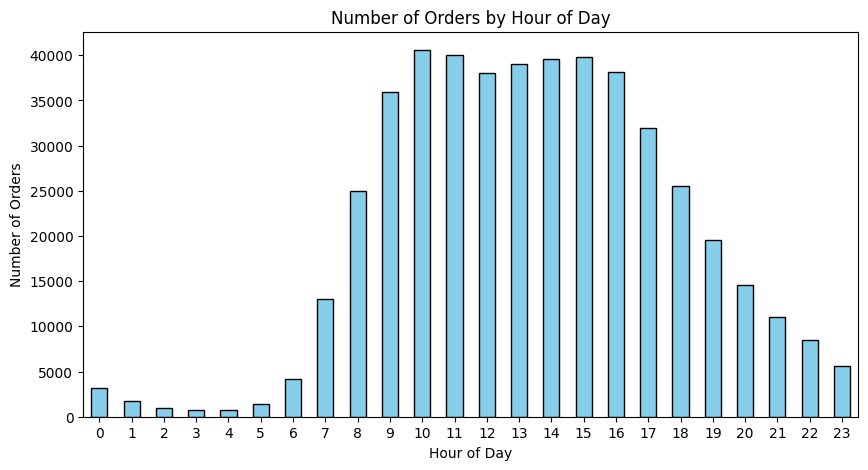

In [33]:
# Count orders by hour and sort by hour
orders_by_hour = orders['order_hour_of_day'].value_counts().sort_index()

# Display counts
print(orders_by_hour)

# Create bar chart
orders_by_hour.plot(
    kind='bar',
    figsize=(10, 5),
    color='skyblue',
    edgecolor='black'
)

plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Clear and complete: you computed counts by hour, produced a well-labeled plot, and summarized the main shopping window and peak hours accurately.

</div>


### [A3] What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

Visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


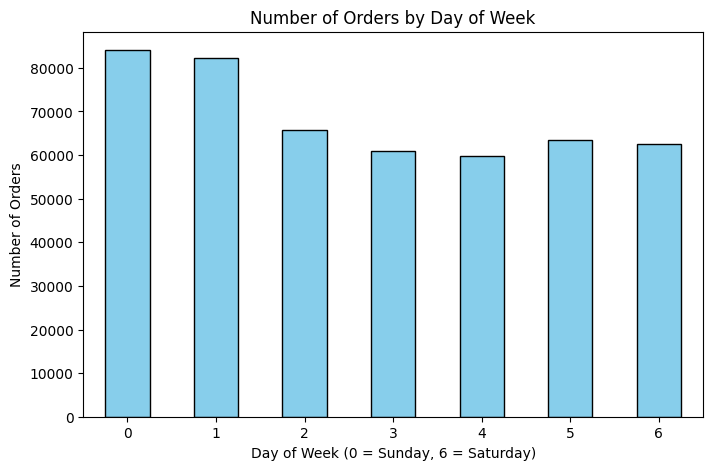

In [34]:
# Count orders by day of week and sort by day number
orders_by_day = orders['order_dow'].value_counts().sort_index()

# Display counts
print(orders_by_day)

# Create bar chart
orders_by_day.plot(
    kind='bar',
    figsize=(8, 5),
    color='skyblue',
    edgecolor='black'
)

plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week (0 = Sunday, 6 = Saturday)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Well done: the day-of-week counts are correctly computed and plotted, and your interpretation matches the visualization (with a clear note about the day-number mapping assumption).

</div>


### [A4] How long do people wait until placing another order?

To understand how long people wait before placing another order, analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

Visualize the data using a bar plot to observe patterns in ordering frequency over time.

0.0      9589
1.0     20179
2.0     27138
3.0     30224
4.0     31006
5.0     30096
6.0     33930
7.0     44577
8.0     25361
9.0     16753
10.0    13309
11.0    11467
12.0    10658
13.0    11737
14.0    13992
15.0     9416
16.0     6587
17.0     5498
18.0     4971
19.0     4939
20.0     5302
21.0     6448
22.0     4514
23.0     3337
24.0     3015
25.0     2711
26.0     2640
27.0     2986
28.0     3745
29.0     2673
30.0    51337
Name: days_since_prior_order, dtype: int64


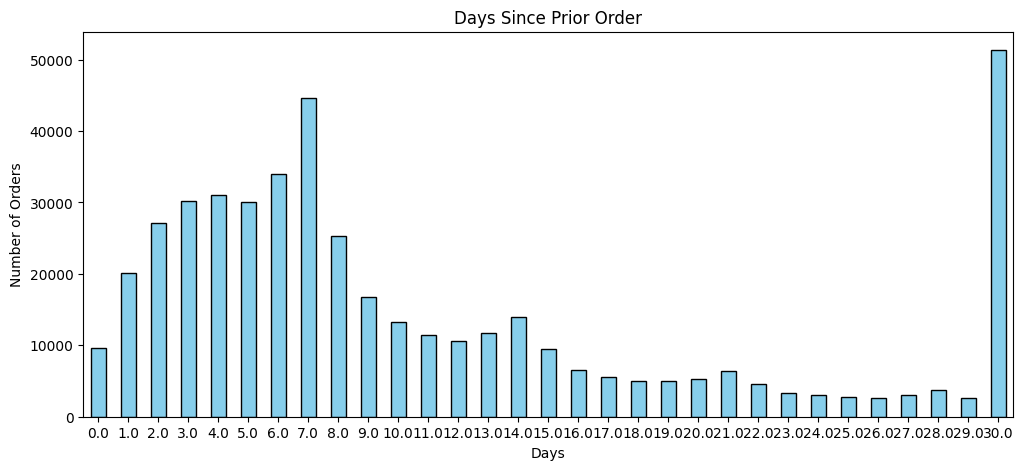

In [35]:
# Count orders by days since prior order
days_between_orders = (
    orders['days_since_prior_order']
    .value_counts()
    .sort_index()
)

# Display counts
print(days_between_orders)

# Create bar chart
days_between_orders.plot(
    kind='bar',
    figsize=(12, 5),
    color='skyblue',
    edgecolor='black'
)

plt.title('Days Since Prior Order')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong analysis: the distribution plot is clearly labeled, and your commentary does a nice job calling out the weekly peak and the recurring spikes (14/21/28/30) with reasonable interpretation.

</div>


# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the bar charts for both days and describe the differences that you see.

To determine if there's a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, follow these steps:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, plot bar charts for both days to visually compare the distribution of order times. Look for patterns such as peaks or differences in the busiest times throughout the day.

wednesday = orders[orders['order_dow'] == 3]
saturday = orders[orders['order_dow'] == 6]

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Those assignments (`wednesday = ...`, `saturday = ...`) are in a markdown cell, so they won’t execute (and they’re not referenced later). Consider moving them into a code cell if you want to use them, or remove them to keep the notebook clean and reproducible.

</div>


In [36]:
wed_hours = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sat_hours = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

In [37]:
hour_comparison = pd.concat([wed_hours, sat_hours], axis=1)
hour_comparison.columns = ['Wednesday', 'Saturday']


<AxesSubplot:>

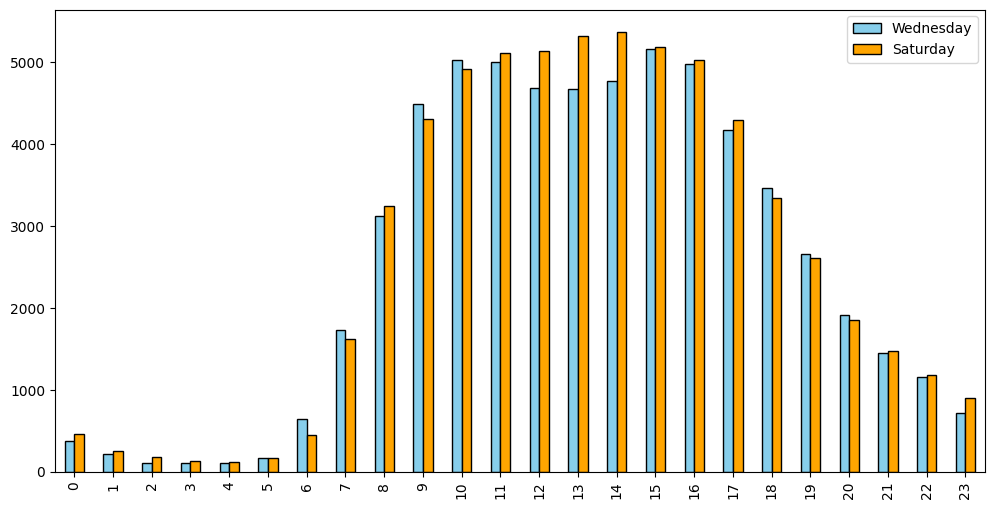

In [38]:
hour_comparison.plot(
    kind='bar',
    figsize=(12, 6),
    color=['skyblue', 'orange'],
    edgecolor='black'
)

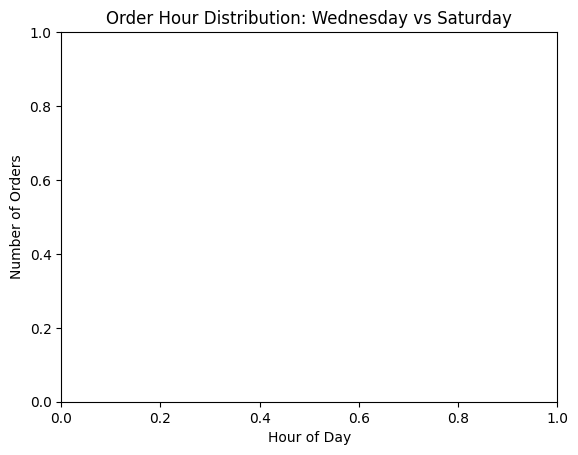

In [39]:
plt.title('Order Hour Distribution: Wednesday vs Saturday')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### [B2] What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

Adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [40]:
orders_per_user = orders.groupby('user_id')['order_id'].count().sort_values()

print(orders_per_user.head())

user_id
152331    1
139876    1
60408     1
139873    1
139871    1
Name: order_id, dtype: int64


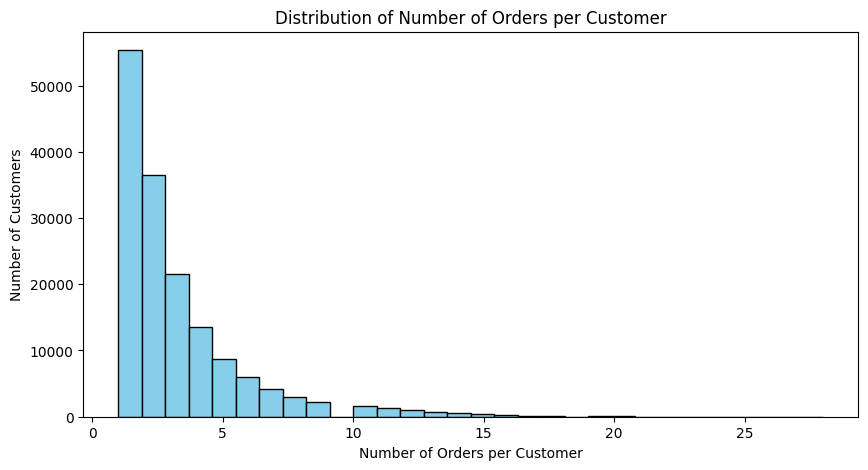

In [41]:
plt.figure(figsize=(10, 5))

orders_per_user.plot(
    kind='hist',
    bins=30,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Number of Orders per Customer')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')

plt.show()

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Complete and well presented: you computed orders per customer, plotted an appropriate histogram with labels/title, and provided a clear takeaway about the distribution.

</div>


### [B3] What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give you a clear view of the most popular products and their ranking.


In [42]:
merged = order_products.merge(products, on='product_id')

In [43]:
top_products = (
    merged
    .groupby(['product_id', 'product_name'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print(top_products)

product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
dtype: int64


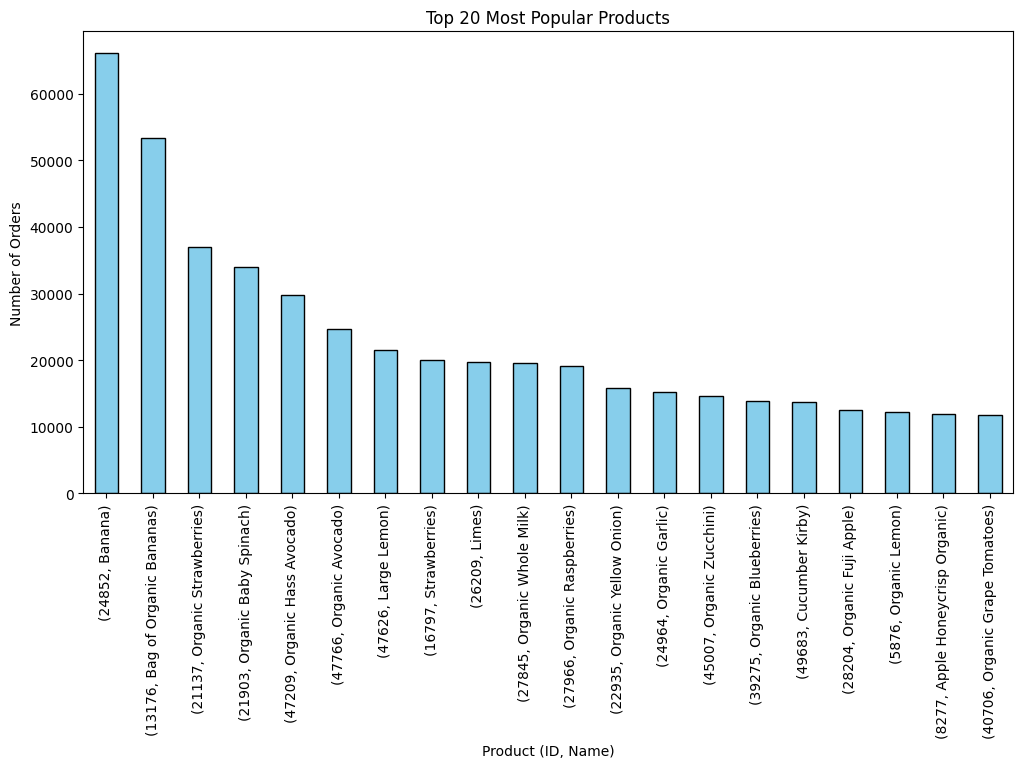

In [44]:
top_products.plot(
    kind='bar',
    figsize=(12, 6),
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 20 Most Popular Products')
plt.xlabel('Product (ID, Name)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)

plt.show()

The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Complete and correct: the merge, top-20 computation (with IDs and names), and the labeled visualization are all done well.

</div>


# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help you understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [45]:
items_per_order = order_products.groupby('order_id')['product_id'].count()

In [46]:
filtered_items = items_per_order[items_per_order < 35]

Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

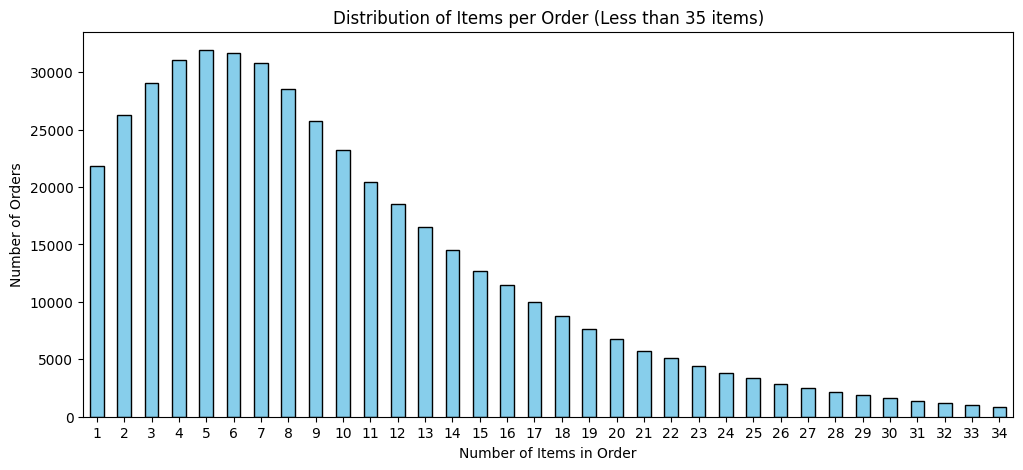

In [47]:
plt.figure(figsize=(12, 5))

filtered_items.value_counts().sort_index().plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Items per Order (Less than 35 items)')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice approach: you calculated items per order and handled the long tail by filtering for readability, resulting in a clear, well-labeled plot.

</div>


The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

To find the top 20 most frequently reordered items:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.

This process highlights the products that customers consistently return to and reorder.

In [48]:
reordered_items = order_products[order_products['reordered'] == 1]

In [49]:
reordered_merged = reordered_items.merge(products, on='product_id')

In [50]:
top_reordered = (
    reordered_merged
    .groupby(['product_id', 'product_name'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print(top_reordered)

product_id  product_name            
24852       Banana                      55763
13176       Bag of Organic Bananas      44450
21137       Organic Strawberries        28639
21903       Organic Baby Spinach        26233
47209       Organic Hass Avocado        23629
47766       Organic Avocado             18743
27845       Organic Whole Milk          16251
47626       Large Lemon                 15044
27966       Organic Raspberries         14748
16797       Strawberries                13945
26209       Limes                       13327
22935       Organic Yellow Onion        11145
24964       Organic Garlic              10411
45007       Organic Zucchini            10076
49683       Cucumber Kirby               9538
28204       Organic Fuji Apple           8989
8277        Apple Honeycrisp Organic     8836
39275       Organic Blueberries          8799
5876        Organic Lemon                8412
49235       Organic Half & Half          8389
dtype: int64


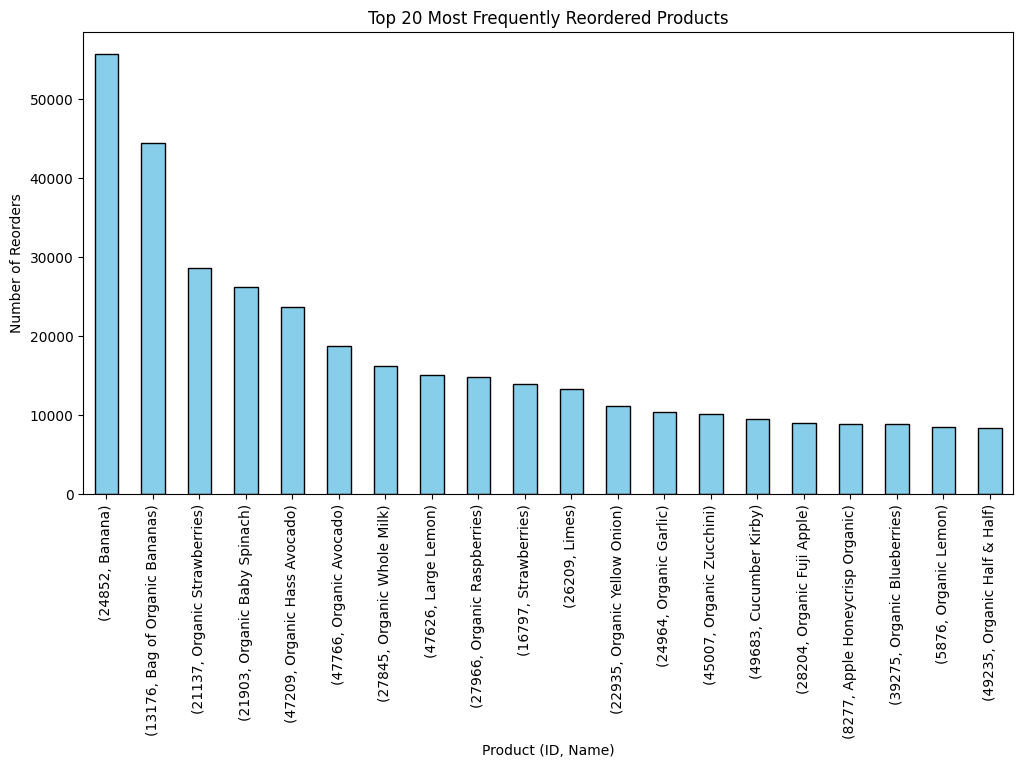

In [51]:

plt.figure(figsize=(12, 6))

top_reordered.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 20 Most Frequently Reordered Products')
plt.xlabel('Product (ID, Name)')
plt.ylabel('Number of Reorders')
plt.xticks(rotation=90)

plt.show()


It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Complete: you correctly identified the top 20 most frequently reordered items (with IDs and names), visualized them, and added a sensible interpretation.

</div>


### [C3] For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.

This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


In [53]:
merged = order_products.merge(products, on='product_id')

product_reorder_rate = (
    merged
    .groupby(['product_id', 'product_name'])['reordered']
    .mean()
    .reset_index()
    .sort_values(by='reordered', ascending=False)
)

In [54]:
print(product_reorder_rate.head(20))

       product_id                                       product_name  \
16218       18121                            Jalapenos With Sea Salt   
24582       27387                         Banana Greek Nonfat Yogurt   
15913       17773                             Quinoa- with Olive Oil   
43954       49063                       Rosemary & Sea Salt Crackers   
13355       14935                           Kombucha Blueberry Basil   
43953       49062  Superior Preference Fade-Defying Color + Shine...   
5320         5924  Pearls Elite Extra Strength Probiotics Dietary...   
37656       42050                   Ultragrain Tortillas 8 Taco Size   
37646       42038                          Scalp Intensive Treatment   
13238       14802                               Black Pepper Chicken   
15892       17749                       Honey Roasted Sliced Almonds   
35770       39926                    California Almond French Twists   
13360       14940                Organic Thick & Chunky Medium S

import matplotlib.pyplot as plt

top_products = product_reorder_rate.head(20)

plt.figure(figsize=(12,6))
plt.bar(top_products['product_name'], top_products['reordered'])
plt.xticks(rotation=90)
plt.title('Top 20 Products by Reorder Rate')
plt.ylabel('Reorder Rate')
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The plotting code for the reorder-rate chart is in a markdown cell, so it won’t run and the figure won’t be generated. Consider moving this block into a code cell so the notebook executes end-to-end.

</div>


The products with the highest reorder rates are mostly staple grocery items such as fresh produce, dairy, and other everyday essentials. These products tend to have very high reorder proportions, meaning customers frequently repurchase them after the initial purchase. This suggests that the highest reorder rates are associated with essential and regularly consumed items rather than occasional or luxury products.

### [C4] For each customer, what proportion of their products ordered are reorders?

To calculate the proportion of products reordered by each customer:

1. **Merge the datasets**: Combine `order_products` with `orders` to link order and customer information.
2. **Group the data**: Group by `user_id` to focus on each customer's ordering behavior.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to determine the proportion of products reordered by each customer.
4. **Sort the results**: Use `.sort_values(ascending=False)` to identify customers with the highest reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to format the grouped data into a structured DataFrame for further analysis.

This analysis reveals the extent to which individual customers reorder products, providing insights into customer loyalty and preferences.


In [55]:
merged = order_products.merge(orders, on='order_id')

In [56]:

user_reorder_rate = (
    merged
    .groupby('user_id')['reordered']
    .mean()
    .reset_index()
    .sort_values(by='reordered', ascending=False)
)


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You computed the per-customer reorder proportion, but the results aren’t shown or summarized yet. Consider displaying a sample (e.g., `.head()`), adding summary stats (e.g., `.describe()`), and/or plotting a histogram so it’s clear what reorder proportions typically look like across customers.

</div>


### [C5] What are the top 20 items that people put in their carts first?

To identify the top 20 items that people most frequently add to their carts first:

1. **Merge the datasets**: Combine `order_products` with `products` to link product names and IDs.
2. **Filter the data**: Focus on rows where `add_to_cart_order` equals 1, indicating the first item added to the cart.
3. **Group the data**: Group by `product_id` and `product_name` to aggregate the count of how often each product was the first in a cart.
4. **Count occurrences**: Use `.count()` to calculate the total number of times each product was the first added.
5. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their first-in-cart frequency.
6. **Display the top 20**: Use `.head(20)` to extract the most popular first-in-cart items.

This provides insights into which products customers prioritize in their shopping process.


In [57]:
merged = order_products.merge(products, on='product_id')

In [58]:
first_in_cart = merged[merged['add_to_cart_order'] == 1]

In [59]:
top_first_items = (
    first_in_cart
    .groupby(['product_id', 'product_name'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print(top_first_items)

product_id  product_name               
24852       Banana                         15562
13176       Bag of Organic Bananas         11026
27845       Organic Whole Milk              4363
21137       Organic Strawberries            3946
47209       Organic Hass Avocado            3390
21903       Organic Baby Spinach            3336
47766       Organic Avocado                 3044
19660       Spring Water                    2336
16797       Strawberries                    2308
27966       Organic Raspberries             2024
44632       Sparkling Water Grapefruit      1914
49235       Organic Half & Half             1797
47626       Large Lemon                     1737
196         Soda                            1733
38689       Organic Reduced Fat Milk        1397
26209       Limes                           1370
12341       Hass Avocados                   1340
5785        Organic Reduced Fat 2% Milk     1310
27086       Half & Half                     1309
43352       Raspberries      

The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.

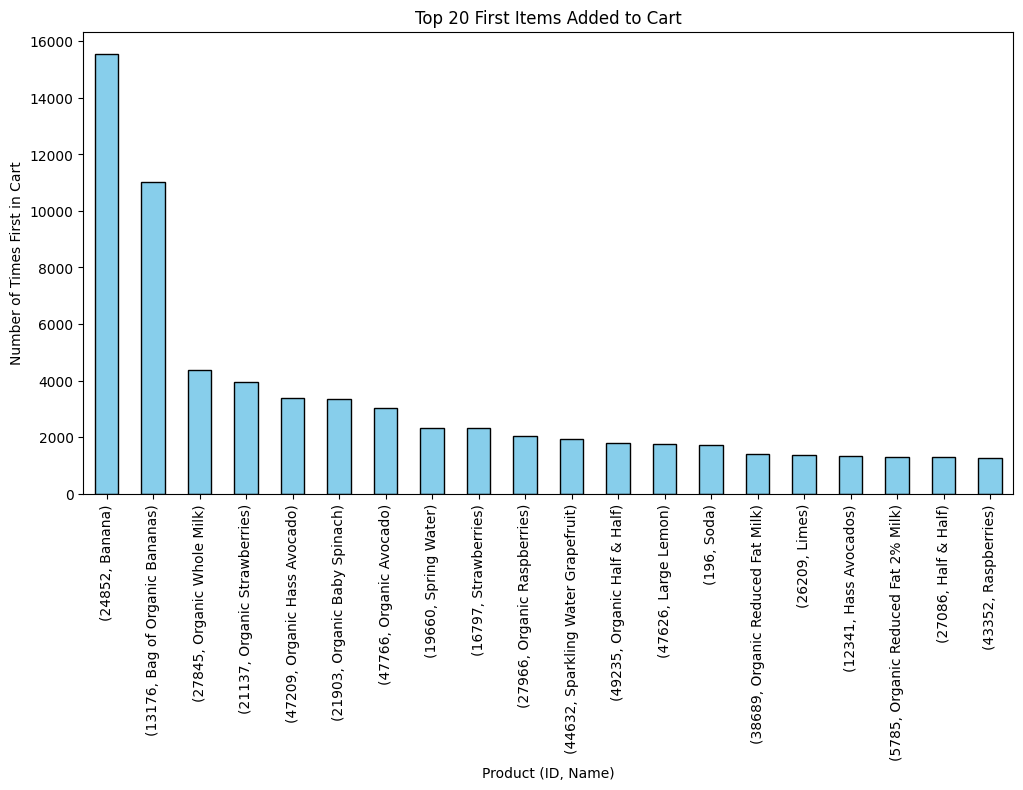

In [60]:
plt.figure(figsize=(12, 6))

top_first_items.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 20 First Items Added to Cart')
plt.xlabel('Product (ID, Name)')
plt.ylabel('Number of Times First in Cart')
plt.xticks(rotation=90)

plt.show()